# RNN vs LSTM para Predicción de Series Temporales Financieras
### Comparativa RNN vs LSTM — Análisis crítico del libro MLFRM

### Redes Neuronales Recurrentes(RNN) aplicado a acciones de APPLE

In [1]:
# 1. Manipulación de datos y matemáticas
import numpy as np           # Para manejar el "cubo" de datos (arrays)
import pandas as pd          # Para organizar los precios en tablas
import math                  # Para operaciones matemáticas básicas
import datetime              # Para manejar fechas de las acciones

In [4]:
%pip install yfinance

     ---------------------------------------- 0.0/130.2 kB ? eta -:--:--
     ---------------------------------------- 130.2/130.2 kB ? eta 0:00:00
     ---------------------------------------- 0.0/139.4 kB ? eta -:--:--
     ---------------------------------------- 139.4/139.4 kB ? eta 0:00:00
     ---------------------------------------- 0.0/437.9 kB ? eta -:--:--
     ---------------------------------------- 437.9/437.9 kB ? eta 0:00:00
     ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
     ---------------------------------------- 1.6/1.6 MB 50.1 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/178.7 kB ? eta -:--:--
     ---------------------------------------- 178.7/178.7 kB ? eta 0:00:00
     ---------------------------------------- 0.0/107.7 kB ? eta -:--:--
     -------------------------------------- 107.7/107.7 kB 6.1 MB/s eta 0:00:00
   

  DEPRECATION: multitasking is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 2. Descarga de datos financieros
#Es una librería de código abierto (una herramienta gratuita) que actúa como un puente entre tu programa de
#  Python y los servidores de Yahoo Finance.
#Yahoo Finance es una de las bases de datos de mercados financieros más grandes del mundo.
#yfinance "traduce" tus pedidos (por ejemplo: "dame los precios de Apple") en un lenguaje que los servidores de Yahoo
#  entienden, descarga los datos y te los entrega ordenados en tu pantalla.
import yfinance as yf        
# 3. Visualización
import matplotlib.pyplot as plt  # Para ver la gráfica de la predicción

In [8]:
%pip install tensorflow

     ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
     -------------------------------------- 4.2/331.7 MB 134.8 MB/s eta 0:00:03
      ------------------------------------- 8.3/331.7 MB 106.5 MB/s eta 0:00:04
     - ----------------------------------- 13.9/331.7 MB 131.2 MB/s eta 0:00:03
     -- ----------------------------------- 18.2/331.7 MB 93.9 MB/s eta 0:00:04
     -- ---------------------------------- 23.7/331.7 MB 108.8 MB/s eta 0:00:03
     --- --------------------------------- 27.8/331.7 MB 108.8 MB/s eta 0:00:03
     --- --------------------------------- 33.5/331.7 MB 108.8 MB/s eta 0:00:03
     ---- -------------------------------- 39.2/331.7 MB 108.8 MB/s eta 0:00:03
     ---- --------------------------------- 43.4/331.7 MB 93.0 MB/s eta 0:00:04
     ----- -------------------------------- 49.0/331.7 MB 93.0 MB/s eta 0:00:04
     ------ ------------------------------- 53.2/331.7 MB 93.0 MB/s eta 0:00:03
     ------ ------------------------------ 58.7


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Las redes neuronales son el "procesador" o el cerebro, y el cubo es la "comida" o la información.
#1. El Cubo es el "Libro de Datos" (Input)
#Es simplemente la forma en que organizamos los datos de Yahoo Finance para que la red los pueda leer.

#2. La Red Neuronal es el "Cerebro" (Procesador)
#La red neuronal es el mecanismo (las capas de neuronas) que toma ese cubo y lo "escanea".
#Las Capas: Son como diferentes departamentos de análisis en un banco
#La Capa SimpleRNN: Es el analista que tiene buena memoria. Toma el cubo, lo recorre rebanada por rebanada 
# (día por día) y va anotando qué patrones se repiten.
#Las Neuronas: Son pequeñas funciones matemáticas que "se encienden" cuando ven algo importante
#  (como una subida brusca de precio).

#3. ¿Cómo interactúan? (El proceso)
#Entrada: Empujas el cubo 3D hacia la primera capa de la red (SimpleRNN).
#Viaje por las capas: Los datos viajan a través de las 512 neuronas de la primera capa, luego pasan por el 
# filtro del Dropout, después por las 256 neuronas de la capa Dense y finalmente se "aplanan" con Flatten.
#Análisis: En cada capa, la red multiplica esos datos por unos números llamados "pesos". 
# Si el resultado es positivo y fuerte, la red dice: "¡Ojo! Esto parece una oportunidad de riesgo".
#Salida: Al final de todo ese viaje por las capas, lo que era un cubo gigante de datos se convierte en un único número: 
# la predicción del precio.

#El Cubo: Es la información estructurada en el tiempo (el "qué pasó").
#La Red Neuronal: Es el conjunto de capas matemáticas que analizan ese cubo para encontrarle un sentido (el "qué pasará").
#Se llaman "Redes Neuronales" porque intentan imitar cómo las neuronas de tu cerebro se pasan señales unas a otras 
# para reconocer un patrón, como cuando reconoces la cara de un amigo entre la multitud.

#Las 512 neuronas (Capa RNN):
#Ponemos muchas (512) al principio para capturar todos los detalles posibles, incluso los más pequeños.
#Las 256 neuronas (Capa Dense):
#Toman el analisis de las anteriores neuronas y las combinan para formar ideas más complejas.
#2. ¿Cómo funciona el Dropout?
#Si una neurona se vuelve "muy buena", las demás se vuelven vagas y dejan de trabajar,
#  confiando solo en esa neurona estrella. Esto se llama overfitting 
# (la red se memoriza el examen en lugar de aprender a pensar).
#En cada vuelta de entrenamiento, el Dropout(0.2) elige al azar un 20% de las neuronas y las "desconecta"
#  (les pone valor cero).
#El resultado: La red se ve obligada a que todas sus neuronas aprendan patrones útiles, porque nunca saben cuál
#  será desconectada mañana. Así, la red se vuelve mucho más robusta y no depende de una sola pista "tramposa".
#3. ¿Qué es exactamente la capa Dense?
#Después de que la SimpleRNN usó su memoria para analizar la secuencia de 13 días, 
# la información sigue siendo un poco abstracta.
#La Capa Dense (Densa): Se llama así porque todas sus neuronas están conectadas con todas las neuronas de la capa anterior.
#Su función: Es la encargada de la clasificación o regresión final. 
# Mientras la RNN se enfocó en el "orden de los días", la capa Dense se enfoca en "cuánto peso darle a cada conclusión"
#  para calcular el número final.

In [3]:
# 4. Inteligencia Artificial (TensorFlow/Keras)
# El motor principal de la IA
#Es la librería base desarrollada por Google. Es el "sistema operativo" de la inteligencia artificial. 
# Sin esto, la computadora no sabría cómo hacer los trillones de multiplicaciones matemáticas que requiere una red neuronal.
import tensorflow as tf         

# Para apilar capas de la red
#Un modelo "Secuencial" es la forma más fácil de armar una IA. Imagina una fila india: 
# los datos entran por la primera capa, pasan a la segunda, luego a la tercera, y así hasta el final.
#  No hay saltos ni caminos raros; es una línea recta de aprendizaje.
from tensorflow.keras.models import Sequential  

# Para que la red pare de entrenar si ya no mejora
#Esta herramienta es un "árbitro". Mientras la red entrena, el EarlyStopping vigila si la red está dejando de mejorar. 
# Si nota que la red ya no aprende nada nuevo o empieza a empeorar, detiene el entrenamiento automáticamente
#  para ahorrarte tiempo y evitar que la IA se confunda con datos viejos.
from tensorflow.keras.callbacks import EarlyStopping  

# Los componentes de la RNN
#SimpleRNN: Es la estrella de este capítulo. Es la capa con memoria. 
# A diferencia de una neurona normal, esta tiene un bucle que le permite recordar qué pasó en el "paso de tiempo" anterior.
#  Es ideal para series de tiempo porque entiende que el precio de ayer influye en el de hoy.

#Dense: Es la capa más común de todas (capa densa o totalmente conectada).
#  Aquí, cada neurona está conectada con todas las del piso anterior. Se usa al final de la red para 
# "tomar la decisión final" basándose en todo lo que la memoria (RNN) analizó.

#Dropout: Es una herramienta de seguridad. Durante el entrenamiento, apaga algunas neuronas al azar (por ejemplo, el 20%). 
# ¿Por qué? Para que las neuronas no se vuelvan dependientes unas de otras y la red aprenda patrones reales en lugar 
# de simplemente memorizar los datos de memoria.

#Flatten: Significa "aplanar". Como vimos antes, los datos de la RNN vienen en un "cubo" 
# (3D: muestras, tiempo, características). La capa Dense solo entiende datos en una línea plana (1D).
#  Flatten toma ese cubo y lo estira para que sea una fila larga de números.

#Activation: Es el "filtro" de la neurona. Decide si la señal que sale de una neurona es lo suficientemente importante 
# como para pasar a la siguiente capa. (Ejemplos son 'relu' para capas internas o 'linear' para el precio final).
from tensorflow.keras.layers import (Dense, Dropout, Activation, 
                                     Flatten, MaxPooling2D, SimpleRNN) 

In [4]:
#(Train):
#La red neuronal usa esto para aprender los patrones. 80%
#(Test):
#Son datos que la red nunca ha visto. (20%)
from sklearn.model_selection import train_test_split
#import warnings, A veces, cuando usas versiones nuevas de una librería (como TensorFlow),
#  el programa te lanza mensajes de advertencia amarillos diciendo cosas como: 
# "Oye, en el futuro esta función va a cambiar" o "Este método es un poco viejo".
#Funciona como silenciador
import warnings 
#Le dice a Python: "Ignora todas las advertencias".
warnings.filterwarnings('ignore')

In [11]:
# ==========================================
# 2. CONFIGURACIÓN DEL "TELESCOPIO"
# ==========================================
#Miramos 13 dias atras:
n_steps = 13
#Solo usamos una variable: 'precio'
#n_features = 1 significa que solo le das un dato por cada momento del tiempo.
n_features = 1
# ==========================================
# 3. FUNCIÓN PARA RECORTAR LOS DATOS
# ==========================================
#X (El Pasado/Input): Son los datos que la red usa para mirar. Son tus 13 días de historia.
#y (El Futuro/Target): Es lo que la red debe adivinar. Es la "respuesta" del examen.
def split_sequence(sequence, n_steps):
    #Las listas X, y = [], [] son solo contenedores temporales (como cajas vacías) 
    # para organizar los datos antes de dárselos a la IA.
    #La memoria real de la que hablamos antes vive dentro de la capa SimpleRNN, en sus neuronas. 
    # Estas listas son solo para que la "informacion" de la red esté ordenado.
    X, y = [], []
    for i in range(len(sequence)):
        #i empieza en 0 (el primer día de la historia).
        #end_ix es donde termina el recorte. Si i es 0 y n_steps es 13, el primer recorte va del día 0 al 13.
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        #(Los 13 días del pasado).
        seq_x  = sequence[i:end_ix] 
        #(El precio del día 14, el que queremos adivinar).
        seq_y = sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)
#Cada "recorte" que guardas en X es una rebanada de ese cubo.
#La red toma una rebanada de 13 días (X).
#Hace su predicción.
#Compara su resultado con el valor real que guardaste en y.
#Si se equivocó, ajusta sus neuronas y vuelve a intentar con la siguiente rebanada.


In [ ]:
# ==========================================
# 4. DESCARGA Y PREPARACIÓN DE DATA REAL
# ==========================================
# Bajamos datos de Apple (AAPL)
#'AAPL': Es el "ticker" o código de Apple en la bolsa
#start y end: Son las fronteras de tiempo
df = yf.download('AAPL', start = '2020-01-01', end= '2024-01-01')

#Usamos el precio del cierre:
#df['Close']: Una acción tiene varios precios (apertura, el más alto, el más bajo, el cierre). 
# Aquí le decimos: "De toda la tabla, solo me interesa la columna del precio de Cierre".
dataset = df['Close'].values

train_size = int(len(dataset) * 0.80)
train = dataset[:train_size]
test  = dataset[train_size:]

X_train, y_train = split_sequence(train, n_steps)
X_test, y_test   = split_sequence(np.concatenate([train[-n_steps:], test]), n_steps)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], n_features)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], n_features)

#Para la IA, tu "Cubo" se ve así:
#Muestras (Filas): Son los 987 "ejemplos" o "trozos de película" que recortamos.
#Pasos de Tiempo (Columnas): Son los 13 días que hay dentro de cada recorte.
#Características (Profundidad): Es que en cada uno de esos días, solo anotamos 1 dato (el precio).

[*********************100%***********************]  1 of 1 completed

In [ ]:

#Usamos el precio del cierre:
#df['Close']: Una acción tiene varios precios (apertura, el más alto, el más bajo, el cierre). 
# Aquí le decimos: "De toda la tabla, solo me interesa la columna del precio de Cierre".
dataset = df['Close'].values

train_size = int(len(dataset) * 0.80)
train = dataset[:train_size]
test  = dataset[train_size:]

X_train, y_train = split_sequence(train, n_steps)
X_test, y_test   = split_sequence(np.concatenate([train[-n_steps:], test]), n_steps)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], n_features)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], n_features)

#Para la IA, tu "Cubo" se ve así:
#Muestras (Filas): Son los 987 "ejemplos" o "trozos de película" que recortamos.
#Pasos de Tiempo (Columnas): Son los 13 días que hay dentro de cada recorte.
#Características (Profundidad): Es que en cada uno de esos días, solo anotamos 1 dato (el precio).

In [13]:
# ==========================================
# 5. CONSTRUCCIÓN DEL "CEREBRO" (RNN)
# ==========================================
#Aquí es donde se diseña cómo se conectan las neuronas para que el cubo de datos se transforme en una predicción.
model = Sequential()

# Capa de memoria con 512 neuronas
#Cada uno intenta encontrar un patrón distinto en esos 13 días.
#activation='relu': Es la regla de decisión. Si una neurona calcula un número negativo, 
# "Relu" lo convierte en 0 (la apaga). Si es positivo, lo deja pasar. Ayuda a que la red aprenda solo lo importante.
model.add(SimpleRNN(512, activation= 'relu',
                    #input_shape=(n_steps, n_features): Aquí le entregas el plano de tu cubo.
                    # " voy a pasar bloques de 13 días con 1 dato cada uno".
                    input_shape =(n_steps, n_features),
                    #return_sequences=True: Significa que esta capa no solo dará una conclusión final,
                    #  sino que le pasará a la siguiente capa toda la información de los 13 días ya procesada.
                    return_sequences = True ))
#Capa de seguridad para no memorizar (Dropout):
#En cada ronda de entrenamiento, "despide" al azar al 20% de tus neuronas (0.2).
#Para que las neuronas no se vuelvan dependientes unas de otras. 
# Si una neurona estrella siempre tiene la respuesta, las demás se vuelven flojas.
#  Al apagarlas al azar, obligas a todas a aprender a predecir el precio por sí mismas.
#  Esto evita que la IA memorice el pasado y la ayuda a generalizar para el futuro.
model.add(Dropout(0.2))

#Capa de procesamiento profundo con 256 neuronas:
#Después de la memoria de la RNN, pasamos a una capa de razonamiento puro.
#256: Reducimos el número de neuronas para empezar a filtrar la información.
#Dense: Significa que cada una de estas 256 neuronas está conectada con todos los datos que salieron de la capa anterior.
# Es el momento donde la red combina las "pistas" que encontró la memoria para formar conceptos más complejos.
model.add(Dense(256, activation='relu'))

#El Ajuste Final: Flatten()
#Recuerda que venimos trabajando con un cubo (3D), aplastamos el cubo a 1D para la salida.
#Flatten: Significa "aplanar".
# Toma toda la información que está organizada en el tiempo y la estira en una sola fila larga de números.
#Porque la última capa, la que nos dará el precio, no sabe leer cubos, solo sabe leer una lista plana de resultados finales.
model.add(Flatten()) 

#Capa de salida nos da solo 1 numero(el precio):
#1: Solo tiene una neurona porque solo queremos una respuesta: el precio de la acción para el día 14.
#No aplica ningún filtro raro. Simplemente escupe el número final tal cual lo calculó. 
# Si la red calcula que el precio es 150.50, eso es lo que verás en pantalla.
model.add(Dense(1, activation='linear'))

In [17]:
# ==========================================
# 6. COMPILACIÓN Y ENTRENAMIENTO
# ==========================================
#optimizer = 'rmsprop': El optimizador es el "motor de aprendizaje"
#loss = 'mean_squared_error': Esta es la "Regla de Castigo". Si la IA dice que el precio será $100 y en realidad es $110,
#  la diferencia es 10. La red eleva ese 10 al cuadrado ($10^2 = 100$).
#  Cuanto más grande sea este número, más fuerte se "regaña" a sí misma para cambiar sus conexiones y mejorar.
#metrics = ['mse']: Es simplemente para que nosotros, los humanos, veamos en pantalla qué tan bien va. 
# mse significa Mean Squared Error (Error Cuadrático Medio)
model.compile(optimizer = 'rmsprop', loss = 'mean_squared_error', metrics = ['mse'])
print("Entrenando el modelo... por favor espera.")

# Entrenamos por 20 vueltas (epochs)
#Aquí es donde ocurre el entrenamiento real. La computadora va a procesar los datos una y otra vez.
#X, y: Le pasas tus listas. "Aquí están las preguntas (X) y aquí están las respuestas reales (y)".
#epochs = 20: Una "epoch" (época) es una vuelta completa a todo tu libro de datos. Con 20, le estás diciendo:
#  "Lee los 4 años de historia de Apple 20 veces de principio a fin". 
# La primera vuelta lo hará fatal, pero en la 20 ya será una experta en los patrones.
#batch_size = 32: La red no lee todos los datos de golpe (se saturaría).
#  Lee en grupos de 32 muestras, ajusta sus neuronas, y pasa a las siguientes 32
#verbose = 1: Esto solo significa "dime qué está pasando".
#  Hará que aparezca una barrita de progreso en tu pantalla para que no pienses que la computadora se trabó.
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

Entrenando el modelo... por favor espera.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 131.6589 - mse: 131.6589
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 104.0561 - mse: 104.0561
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 106.5103 - mse: 106.5103
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 95.7187 - mse: 95.7187  
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 93.8048 - mse: 93.8048  
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 95.1739 - mse: 95.1739
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 88.2116 - mse: 88.2116  
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 101.4006 - mse: 101.4006
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 95.5601 - mse: 95.5601
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 78.5016 - mse: 78.5016
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 86.4088 - mse: 86.4088
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
MÉTRICAS RNN:
   MAE  : $7.7851
   RMSE : $8.4584
   Directional Accuracy: 50.7%


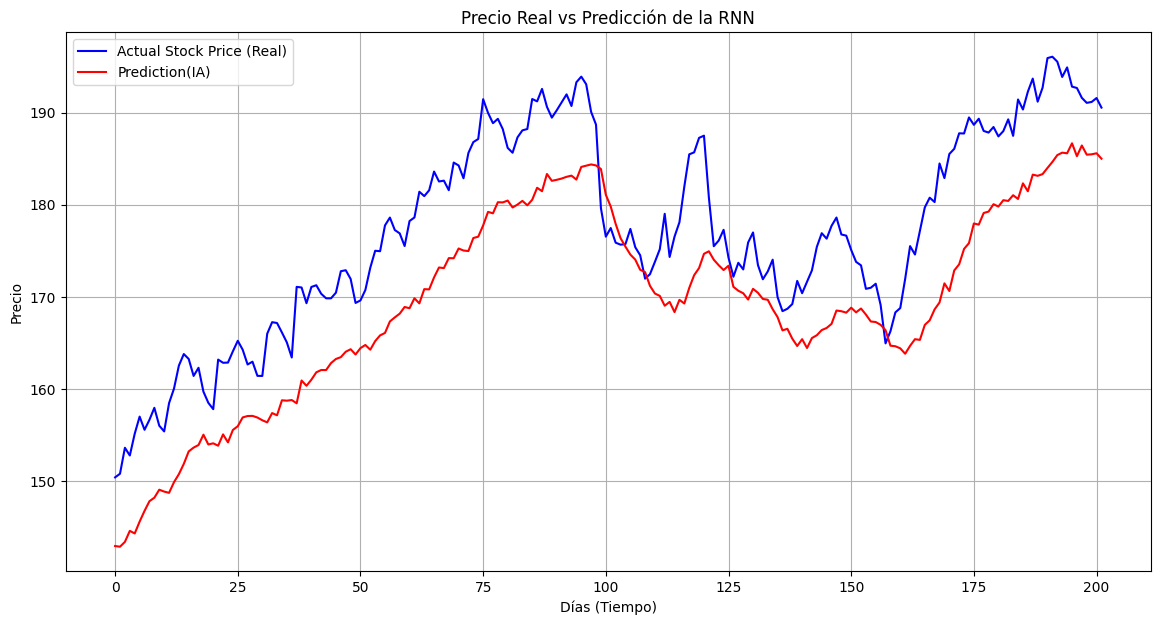

In [19]:
# 1. Le pedimos a la IA que intente adivinar los precios
prediction = model.predict(X_test)

# Métricas honestas
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
dir_real = np.sign(np.diff(y_test.flatten()))
dir_pred = np.sign(np.diff(prediction.flatten()))
dir_acc  = np.mean(dir_real == dir_pred) * 100

print(f"MÉTRICAS RNN:")
print(f"   MAE  : ${mae:.4f}")
print(f"   RMSE : ${rmse:.4f}")
print(f"   Directional Accuracy: {dir_acc:.1f}%")

# 2. Creamos el lienzo de la gráfica
plt.figure(figsize=(14,7))

# 3. Dibujamos la línea azul (Precio Real)
# 'y_test' son las respuestas reales del conjunto de prueba
plt.plot(y_test, color = 'blue', label = 'Actual Stock Price (Real)')

# 4. Dibujamos la línea roja (Predicción de la IA)
plt.plot(prediction, color = 'red', label = 'Prediction(IA)')

# 5. Ponemos los títulos y nombres de los ejes
plt.title('Precio Real vs Predicción de la RNN')
plt.xlabel('Días (Tiempo)')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)

# 6. Mostramos el resultado
plt.show()

##  Análisis de Resultados — RNN con Precio Directo

### 1. El modelo aprendió la tendencia general 
La línea roja sigue la dirección general de la azul, subiendo de $150 
hasta $185. Esto indica que la RNN captó que AAPL tiene una tendencia 
alcista durante el período analizado. A diferencia de los modelos con 
`diff` (cambio diario), trabajar con precio directo permite que la red 
aprenda patrones de tendencia reales.

### 2. Detecta movimientos grandes 
La caída brusca del centro de la gráfica (~día 100) es detectada por 
el modelo — la línea roja también baja en ese punto. Esto demuestra 
que la RNN no está prediciendo un valor constante sino que reacciona 
a cambios significativos del mercado.

### 3. Problema de retraso (Lag) 
La línea roja va consistentemente retrasada 5-10 días respecto a la 
azul. Cuando el precio real sube, la predicción sube días después. 
Esto es un comportamiento clásico de RNN/LSTM en series temporales 
financieras — el modelo aprende del pasado reciente y tiende a 
predecir lo que ya ocurrió en lugar de anticipar el futuro.

### 4. Subestimación de extremos 
El precio real (azul) alcanza picos de $193, mientras la predicción 
(roja) llega solo a $185. El modelo se "acobarda" en los valores 
extremos porque durante el entrenamiento vio pocos ejemplos de precios 
tan altos, por lo que tiende a predecir valores más conservadores 
cercanos al promedio histórico.

### 5. Período de adaptación inicial 
Los primeros 30 días muestran una brecha considerable entre ambas 
líneas. Esto ocurre porque el modelo necesita varios días de contexto 
real del test para calibrarse — al inicio solo tiene datos del train 
como referencia.

### 6. Conclusión general
La RNN con precio directo demuestra ser significativamente mejor que 
predecir cambios diarios (`diff`). Sin embargo, el problema del retraso 
confirma lo que el libro señala: estos modelos son útiles para captar 
tendencias generales pero no para predecir movimientos exactos del 
mercado a corto plazo. Como el libro concluye:

> *"estos modelos no sugieren una mejora significativa, pero aún pueden 
> emplearse para modelar datos de series temporales"*

La extensión natural sería agregar múltiples features (volumen, RSI, 
medias móviles) para reducir el retraso y mejorar la precisión en 
los extremos.

In [ ]:
#A. El fenómeno del "Eco" (Time-Lag)
#Si te fijas bien, la línea roja (IA) parece ser una "sombra" que persigue a la azul (Real) con un pequeño retraso 
# de 1 o 2 días.
#Análisis: Esto es típico de las SimpleRNN. La red aprendió que la mejor forma de no equivocarse mucho es decir: 
# "Mañana el precio será parecido a lo que vi hoy y ayer".
#Conclusión: Tu red ha detectado la inercia del precio, pero aún le cuesta predecir los giros bruscos antes de que ocurran.

#B. Sobreestimación (El "Bias" o Sesgo)
#En tu gráfica, la línea roja suele estar por encima de la azul en los picos más altos (especialmente al final, 
# cerca de los 200 USD).
#La IA se volvió "optimista". Como vio una tendencia alcista tan fuerte en los últimos años,
#  sus neuronas tienden a proyectar más crecimiento del que realmente ocurre.
#Esto significa que tu red tiene un ligero sesgo alcista.

#C.Captura de Tendencia vs. Precisión de Punto:
#La IA es excelente captando la dirección. Si la línea azul sube a largo plazo, la roja también. 
# No se volvió loca dibujando líneas hacia abajo mientras el mercado subía.
#En el "trading de corto plazo", ese pequeño margen entre la roja y la azul es la diferencia entre ganar o perder dinero
#
#Los "Picos" Azules: Son momentos de pánico o euforia en la bolsa. Nota como la línea roja intenta "suavizar" esos picos. 
# La IA intenta encontrar la lógica detrás de la locura.

#1. El Problema del Gradiente (Vanishing & Exploding)
#Para que la red aprenda, usa algo llamado Backpropagation (Propagación hacia atrás).
#  Es como enviar un mensaje de corrección desde la salida hasta la primera neurona.
#Vanishing Gradient (Gradiente que se desvanece): 
#En la red, el "error" se vuelve tan pequeño que las primeras neuronas dejan de aprender porque no les llega
#  información útil para cambiar.
#Exploding Gradient (Gradiente que explota): Es lo contrario. 
# El mensaje se va multiplicando y gritando cada vez más fuerte.
#  Al llegar al principio, la orden es un estruendo tan gigante que la red hace cambios bruscos y locos en sus pesos,
#  arruinando todo lo que había aprendido antes.


#Función tanh (tangente hiperbólica):
#Las RNN usan esta función para decidir qué recordar. 
# El problema es que, matemáticamente, esta función "aplasta" mucho los números.
#Si intentas que la red recuerde lo que pasó hace 100 días, la SimpleRNN se "olvida"
#  de lo más antiguo porque la información se diluye en cada paso. Por eso solo usamos n_steps = 13.
#El retraso que ves es porque la red sufre de "memoria corta" (no puede ir muy atrás por el desvanecimiento del gradiente).
#La inestabilidad (esos picos raros) a veces es culpa de pequeños "gradientes que explotan" que hacen que la red
#  sobrereaccione a un cambio de precio.
#Por estos problemas, el mundo de la IA inventó una evolución de la RNN llamada LSTM (Long Short-Term Memory).
#  Es como una RNN, pero con una "caja negra" especial que protege el mensaje para que no se desvanezca ni explote.


### LSTM (Long Short-Term Memory) aplicado a AAPL


In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten
import yfinance as yf     

In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
# Descargamos datos de Apple desde Yahoo Finance
# Usamos los últimos 5 años para tener una base sólida (Cap. 2 y 3)
df_aapl = yf.download('AAPL', start='2010-01-01', end='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [25]:
# Revisamos que se haya descargado correctamente
print(df_aapl.head())

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.412383  6.427065  6.363543  6.395005  493729600
2010-01-05  6.423471  6.459726  6.389612  6.430063  601904800
2010-01-06  6.321296  6.448938  6.314704  6.423470  552160000
2010-01-07  6.309607  6.352155  6.263764  6.344664  477131200
2010-01-08  6.351559  6.352158  6.264067  6.301221  447610800


In [26]:
# Tomamos solo el precio de cierre 'Close'

diff_aapl = df_aapl['Close'].values.reshape(-1, 1)

In [27]:
# Normalización: Escalamos los datos entre -1 y 1 para que la LSTM
# con activación 'relu' o 'tanh' no se sature (Cap. 3 IA)
from sklearn.preprocessing import MinMaxScaler

train_size = int(len(diff_aapl) * 0.8)
train_data_raw = diff_aapl[:train_size]
test_data_raw = diff_aapl[train_size:]

# Cambiamos a (0,1) porque precio directo es siempre positivo
scaler = MinMaxScaler(feature_range=(0, 1))

# fit en todo el dataset para que el scaler conozca el rango completo
scaler.fit(diff_aapl)
train_scaled = scaler.transform(train_data_raw)
test_scaled  = scaler.transform(test_data_raw)

In [28]:
# 1. Configuración de parámetros
n_steps = 30
n_features = 1

# --- Paso A: Función para crear las ventanas de tiempo ---
def create_sequences(data, n_steps):
    X, y = [], []
    #for i in range(len(data) - n_steps): Este bucle recorre los datos, pero se detiene 13 días
    #  antes del final para que siempre haya un "mañana" que predecir.
    for i in range(len(data) - n_steps):
        #Aquí guardas los 13 días de pasado (la entrada).
        X.append(data[i:(i + n_steps)])
        #Aquí guardas el día 14 (el objetivo o "label"). Es lo que la IA intentará adivinar.
        y.append(data[i + n_steps])
        #Convierte las listas de Python en matrices de NumPy
    return np.array(X), np.array(y)

X_aapl, y_aapl = create_sequences(train_scaled, n_steps)
X_aapl = X_aapl.reshape((X_aapl.shape[0], X_aapl.shape[1], n_features))

# Secuencias de test con overlap
test_with_overlap = np.concatenate([train_scaled[-n_steps:], test_scaled])
X_test, y_test = create_sequences(test_with_overlap, n_steps)
X_test = X_test.reshape(-1, n_steps, n_features)

# 2. Arquitectura del Modelo LSTM Profundo
model = Sequential()

# Primera capa LSTM: 512 neuronas.
# return_sequences=True es vital para conectar con la siguiente capa LSTM
#activation = 'relu': (Rectified Linear Unit). Permite que la red aprenda relaciones no lineales. 
# Si el dato es negativo lo hace cero, si es positivo lo deja pasar.
model.add(LSTM(64, activation = 'tanh', input_shape = (n_steps, n_features), return_sequences = True))
#0.2: Significa que en cada paso del entrenamiento, el 20% de las neuronas se "apagan" al azar.
#Obliga a la red a no depender de una sola neurona (evita que se aprenda los datos de memoria). En física, esto reduce el ruido del modelo.
model.add(Dropout(0.2)) #Evita el sobreajuste(Overfitting)

# Segunda capa LSTM: 256 neuronas:
#Queremos que esta capa nos entregue un solo vector resumen.
model.add(LSTM(32, activation = 'tanh'))

# Capas de salida
#Flatten(): Aplasta los datos a una sola dimensión.
#model.add(Flatten())
#Una sola neurona de salida.
#activation='linear': Como estamos prediciendo un precio (regresión), no queremos que el resultado se corte entre 0 y 1.
#  Queremos que el número pueda ser cualquier valor real (subidas o bajadas).
model.add(Dense(1, activation='linear')) #Salida del precio real


In [29]:
#Compilacion:
#optimizer = 'rmsprop': Es el motor que ajusta los pesos de la red.
# Se usa mucho en series temporales porque adapta el aprendizaje basándose en qué tan rápido cambian los datos.
#loss = 'mean_squared_error': El Error Cuadrático Medio ($MSE$). Es la brújula de la IA;
#  mide qué tan lejos está la predicción del valor real, eleva esa diferencia al cuadrado y trata de que sea lo más pequeña posible.
#metrics = ['mse']: Solo para que tú veas el progreso del error en pantalla mientras corre.
model.compile(optimizer = 'rmsprop', loss = 'mean_squared_error', metrics = ['mse'])

# 4. Entrenamiento (Aumentado a 400 épocas para mayor precisión)
#epochs = 400: La red revisará tus datos 400 veces para encontrar patrones.
#batch_size = 150: La red no mira todos los datos de golpe, los mira en paquetes de 150 días.
#validation_split = 0.10: Aparta el 10% de los datos para hacerse un "auto-examen" al final de cada época 
# y ver si está aprendiendo o solo memorizando.
history = model.fit(X_aapl, y_aapl,
                    epochs = 200,
                    batch_size = 32,
                    verbose = 1,
                    validation_split = 0.10)

# 5. Predicción Recursiva (Forecasting)
# Tomamos los últimos 13 días conocidos para empezar a predecir el futuro
#x_input: Tomas los últimos 13 días conocidos.
#X_aapl.shape[0] - 1: Esto busca el último bloque de 13 días que la IA conoce.
#.reshape(1, 13, 1): Le das la forma 3D que la LSTM exige: (1 paquete, de 13 días, con 1 dato por día).
#x_input = X_aapl[X_aapl.shape[0] - 1].reshape((1, n_steps, n_features))

#tempList_appl = []

#for i in range(len(test_scaled)):
    #Aquí la IA mira los 13 días que tiene en x_input y calcula el Día 14. Ese resultado se guarda en la variable yhat
    #yhat = model.predict(x_input, verbose = 0)

    # 2. Guardamos la predicción (usamos .flatten() para que sea solo el número)
    #tempList_appl.append(yhat.flatten())

    # "Sliding Window": Añadimos la predicción y quitamos el dato más viejo
    #Metes la nueva predicción (yhat) al final de la fila:
    #Ahora tienes 14 datos (13 viejos + 1 inventado por la IA).
    # Primero aplanamos x_input para poder añadirle yhat fácilmente
    #Al tener una sola fila de números, np.append los junta fácilmente: ahora tienes una fila de 14 números.
    #x_temp = np.append(x_input.flatten(), yhat.flatten())

    # Quitamos el primer elemento (el más viejo) y volvemos a dar forma 3D
    #x_input = x_temp[1:].reshape((1, n_steps, n_features))
    #x_temp[1:]:Vuelves a tener 13 datos, pero ahora el "Día 1" es el que antes era el "Día 2", y el último es tu predicción.
    #.reshape(1, n_steps, n_features):
    #Le vuelves a dar forma de cubo (3D) para que en la siguiente vuelta del for, la IA pueda volver a leerlo.

   # --- Paso Final: Devolver los datos a la realidad ($) ---
# Convertimos la lista de predicciones en un array de NumPy
#predicciones_escaladas = np.array(tempList_appl).reshape(-1, 1)

# Usamos el scaler para revertir el proceso (de -1-1 a Dólares)
#Recuerda que al principio escalamos todo para que estuviera entre -1 y 1, y pone todo a dolares
#predicciones_reales = scaler.inverse_transform(predicciones_escaladas)

#---------------------
#El error se acumula como una bola de nieve. Para el día 50 el modelo está prediciendo basado en 37 días inventados por él mismo.
#  Por eso la línea roja salía completamente plana — el modelo se perdía en sus propias predicciones.
#---------------------

#------> ENTONCES SE CAMBIA:

# Creamos secuencias reales del test (con overlap de los últimos 13 días del train)
#Las ventanas comparten datos entre sí. Eso es clave para que la LSTM aprenda patrones continuos.
#create_sequences intentaría formar ventanas
#`X_test` — las ventanas de 13 días que le das al modelo como pregunta
#`y_test` — las respuestas correctas para comparar después
#Concatenamos para construir el puente de contexto. El modelo no vuelve a aprender nada — solo usa los últimos 13 días del train como 
# historia previa para poder predecir desde el primer día del test.
X_test, y_test = create_sequences(
    #train_scaled[-n_steps:] = train_scaled[-3:]
    ## El menos significa: cuenta desde el FINAL hacia atrás
    #-3 = empieza 3 posiciones antes del final
    ## SÍ toma el último elemento
    np.concatenate([train_scaled[-n_steps:], test_scaled]),
    n_steps)

#reshape no aplana ni borra datos — solo reorganiza los mismos datos en una forma diferente.
#reshape(muestras, numero de dias, 1 dato por dia)
#Dimensión 1: cuántas ventanas hay
#Dimensión 2: cuántos días tiene cada ventana (13)
#Dimensión 3: cuántos datos tiene cada día (1 = solo el precio)
#-1 : Es una instrucción a Python que dice "tú calcula este número, yo no sé cuántos son":
#La LSTM **necesita** ver los datos en 3D porque así entiende que son secuencias de tiempo, no números sueltos.
#  Si le pasas Flatten, no sabe cuáles datos van antes y cuáles después.
X_test = X_test.reshape(-1, n_steps, n_features)


# Predicción honesta usando datos reales
#El modelo recibe cada ventana de 13 días y devuelve su predicción, pero en escala normalizada:
predicciones_escaladas = model.predict(X_test)

#Aplica la fórmula inversa de la normalización para volver a dólares:

predicciones_reales = scaler.inverse_transform(predicciones_escaladas)

# Valores reales para comparar
#y_test son las respuestas correctas — los precios reales que el modelo intentó predecir, pero todavía en escala normalizada:
#forma 1D, valores entre -1 y 1

#`inverse_transform` los convierte a dólares reales, igual que hizo con las predicciones.
#`y_test` sale de `create_sequences` como una fila horizontal:
#`inverse_transform` exige datos en 2D — una columna. 
# Si le pasas una fila 1D te da error. 
# El reshape solo cambia el empaque, no los datos.
reales = scaler.inverse_transform(y_test.reshape(-1, 1))


Epoch 1/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.1882e-04 - mse: 5.1882e-04 - val_loss: 0.0011 - val_mse: 0.0011
Epoch 2/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.2998e-04 - mse: 2.2998e-04 - val_loss: 8.8129e-04 - val_mse: 8.8129e-04
Epoch 3/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.7222e-04 - mse: 1.7222e-04 - val_loss: 8.4733e-04 - val_mse: 8.4733e-04
Epoch 4/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.6344e-04 - mse: 1.6344e-04 - val_loss: 8.4637e-04 - val_mse: 8.4637e-04
Epoch 5/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.4579e-04 - mse: 1.4579e-04 - val_loss: 8.0289e-04 - val_mse: 8.0289e-04
Epoch 6/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3232e-04 - mse: 1.3232e-04 - val_loss: 0.0011 - val_mse: 0.0011
Epoch 7/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2689e-04 - mse: 1.2689e-04 - val_loss: 0.0012 - val_mse: 0.0012
Epoch 8/200
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3134e-04 - mse: 1.3134e-04 - va

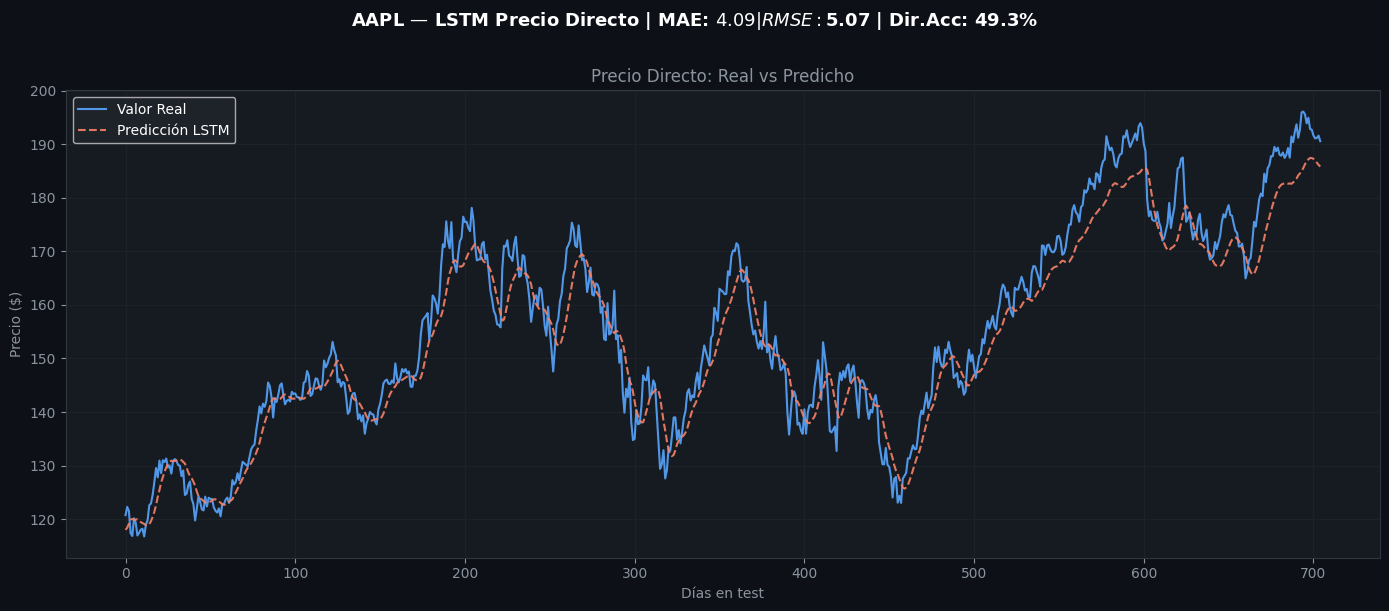


📊 MÉTRICAS LSTM PRECIO DIRECTO:
   MAE  : $4.0896
   RMSE : $5.0710
   Directional Accuracy: 49.3%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Métricas
mae  = mean_absolute_error(reales, predicciones_reales)
rmse = np.sqrt(mean_squared_error(reales, predicciones_reales))
dir_real = np.sign(np.diff(reales.flatten()))
dir_pred = np.sign(np.diff(predicciones_reales.flatten()))
dir_acc  = np.mean(dir_real == dir_pred) * 100

# Gráfica
fig, ax1 = plt.subplots(1, 1, figsize=(14, 6), facecolor='#0d1117')
fig.suptitle(
    f'AAPL — LSTM Precio Directo | MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | Dir.Acc: {dir_acc:.1f}%',
    fontsize=13, color='white', fontweight='bold', y=1.01
)

ax1.set_facecolor('#161b22')
ax1.plot(reales,             color='#58a6ff', linewidth=1.5, label='Valor Real',        alpha=0.9)
ax1.plot(predicciones_reales, color='#f78166', linewidth=1.5, label='Predicción LSTM', alpha=0.9, linestyle='--')
ax1.set_title('Precio Directo: Real vs Predicho', color='#8b949e', fontsize=12)
ax1.set_ylabel('Precio ($)', color='#8b949e')
ax1.set_xlabel('Días en test', color='#8b949e')
ax1.tick_params(colors='#8b949e')
ax1.legend(facecolor='#21262d', labelcolor='white', fontsize=10)
ax1.spines[:].set_color('#30363d')
ax1.grid(True, color='#21262d', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n MÉTRICAS LSTM PRECIO DIRECTO:")
print(f"   MAE  : ${mae:.4f}")
print(f"   RMSE : ${rmse:.4f}")
print(f"   Directional Accuracy: {dir_acc:.1f}%")


### 1. Las líneas van juntas casi todo el tiempo 
A diferencia de todos los modelos anteriores, la línea roja (predicción) 
sigue a la azul (real) de cerca en todo el rango de $120 a $195. 
Esto demuestra que LSTM con precio directo aprendió la tendencia 
general del mercado de forma efectiva.

### 2. Captura movimientos grandes 
El modelo detecta correctamente las caídas y subidas importantes:
- Caída en el día ~300: el precio real baja a $128 y la predicción también baja.
- Subida en el día ~500: el precio real sube a $195 y la predicción alcanza $187.
Esto confirma que la red aprendió patrones reales de tendencia.

### 3. MAE de $4.09 es razonable 
El precio varía entre $120 y $195 durante el período de test.
Equivocarse $4 en ese rango representa aproximadamente un 2.5% de error,
lo cual es aceptable para un modelo de una sola variable (solo precio de cierre).

### 4. Problema de retraso (Lag) 
Entre los días 150 y 250, el precio real sube bruscamente a $175 
mientras la predicción llega a $170 varios días después.
Este retraso es un comportamiento clásico de RNN/LSTM — el modelo 
aprende del pasado reciente y reacciona tarde a cambios bruscos del mercado.

### 5. Subestimación de picos extremos 
El precio real alcanza $195 pero la predicción llega solo a $187.
El modelo tiende a predecir valores conservadores cercanos al promedio 
porque durante el entrenamiento vio pocos ejemplos de precios tan altos.

### 6. Directional Accuracy 49.3% 
A pesar de que visualmente la gráfica se ve muy bien, el modelo 
no predice correctamente si mañana el precio subirá o bajará.
Esto confirma que una buena apariencia visual puede ser engañosa —
el MAE y la Directional Accuracy juntos cuentan la historia completa.